In [27]:
import json
from datetime import datetime
from typing import Dict, List, Any

import pandas as pd
import matplotlib.pyplot as plt

In [28]:
POLICIES = {
    "POL-CAT-01": {
        "name": "Eligible Categories",
        "description": (
            "Reimbursable categories include airfare, lodging, meals, "
            "ground transport, and conference/registration fees."
        )
    },

    "POL-CAT-02": {
        "name": "Ineligible Categories",
        "description": (
            "Alcohol, minibar, spa, gym, personal entertainment, "
            "personal shopping, gifts, traffic fines, penalties, "
            "late fees, and personal expenses are not reimbursable."
        )
    },

    "POL-PD-01": {
        "name": "Meal Per-Diem",
        "description": "Meals are reimbursable up to $75 per day."
    },

    "POL-PD-02": {
        "name": "Lodging Limit",
        "description": "Lodging is reimbursable up to $200 per night."
    },

    "POL-PD-03": {
        "name": "Ground Transport Limit",
        "description": "Ground transport is reimbursable up to $50 per day."
    },

    "POL-AIR-01": {
        "name": "Airfare Class",
        "description": (
            "Only economy airfare is reimbursable. "
            "Business/first class requires Manual Review."
        )
    },

    "POL-RCT-01": {
        "name": "Receipt Requirement",
        "description": (
            "Any single line item above $25 requires an attached "
            "itemized receipt. Airfare and lodging always require receipts."
        )
    },

    "POL-RCT-02": {
        "name": "Missing Receipt",
        "description": (
            "If a required receipt is missing, route the claim "
            "to Manual Review."
        )
    },

    "POL-APR-01": {
        "name": "Auto Approval",
        "description": "Total reimbursable amount <= $500 may be auto-approved."
    },

    "POL-APR-02": {
        "name": "Manager Approval",
        "description": (
            "Total reimbursable amount > $500 and <= $2,000 "
            "is approvable when fully compliant."
        )
    },

    "POL-APR-03": {
        "name": "Director / Manual Review",
        "description": (
            "Total reimbursable amount > $2,000 must be routed "
            "to Manual Review."
        )
    },

    "POL-TIME-01": {
        "name": "Submission Window",
        "description": (
            "Claims must be submitted within 30 days of the expense date."
        )
    }
}

In [29]:
CLAIMS = [
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "trip": {
            "start": "2026-06-10",
            "end": "2026-06-12"
        },
        "submitted": "2026-06-20",
        "items": [
            {
                "category": "airfare",
                "description": "Round-trip economy airfare",
                "amount": 420.00,
                "receipt_attached": True,
                "class": "economy"
            },
            {
                "category": "lodging",
                "description": "Hotel, 2 nights @ $180",
                "amount": 360.00,
                "receipt_attached": True,
                "nights": 2
            },
            {
                "category": "meals",
                "description": "Meals, 3 days @ ~$60/day",
                "amount": 180.00,
                "receipt_attached": True,
                "days": 3
            },
            {
                "category": "conference_fees",
                "description": "Conference registration",
                "amount": 150.00,
                "receipt_attached": True
            }
        ]
    },

    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "trip": {
            "start": "2026-06-14",
            "end": "2026-06-15"
        },
        "submitted": "2026-06-25",
        "items": [
            {
                "category": "spa",
                "description": "Hotel spa package",
                "amount": 300.00,
                "receipt_attached": True
            },
            {
                "category": "minibar",
                "description": "In-room minibar",
                "amount": 80.00,
                "receipt_attached": True
            }
        ]
    },

    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "trip": {
            "start": "2026-06-08",
            "end": "2026-06-10"
        },
        "submitted": "2026-06-22",
        "items": [
            {
                "category": "airfare",
                "description": "Round-trip economy airfare",
                "amount": 300.00,
                "receipt_attached": True,
                "class": "economy"
            },
            {
                "category": "lodging",
                "description": "Hotel, 2 nights @ $250",
                "amount": 500.00,
                "receipt_attached": True,
                "nights": 2
            },
            {
                "category": "meals",
                "description": "Meals, 2 days @ $70/day",
                "amount": 140.00,
                "receipt_attached": True,
                "days": 2
            }
        ]
    },

    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "trip": {
            "start": "2026-06-16",
            "end": "2026-06-18"
        },
        "submitted": "2026-06-28",
        "items": [
            {
                "category": "airfare",
                "description": "Business-class international airfare",
                "amount": 2400.00,
                "receipt_attached": True,
                "class": "business"
            },
            {
                "category": "lodging",
                "description": "Hotel, 3 nights",
                "amount": 600.00,
                "receipt_attached": False,
                "nights": 3
            }
        ]
    },

    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "trip": {
            "start": "2026-06-11",
            "end": "2026-06-11"
        },
        "submitted": "2026-06-24",
        "items": [
            {
                "category": "meals",
                "description": "Client dinner for 4 (business development)",
                "amount": 220.00,
                "receipt_attached": False,
                "days": 1
            }
        ]
    }
]

In [30]:
def policy_lookup(policy_ids: List[str]) -> Dict[str, Any]:
    """
    Retrieve relevant policy information.
    """

    result = {}

    for policy_id in policy_ids:
        if policy_id in POLICIES:
            result[policy_id] = POLICIES[policy_id]

    return result

In [31]:
policy_lookup(["POL-PD-01", "POL-RCT-02"])

{'POL-PD-01': {'name': 'Meal Per-Diem',
  'description': 'Meals are reimbursable up to $75 per day.'},
 'POL-RCT-02': {'name': 'Missing Receipt',
  'description': 'If a required receipt is missing, route the claim to Manual Review.'}}

In [32]:
def receipt_check(claim: Dict[str, Any]) -> Dict[str, Any]:
    """
    Check whether required receipts are available.
    """

    missing_receipts = []

    for item in claim["items"]:

        category = item["category"]
        amount = item["amount"]
        receipt = item.get("receipt_attached", False)

        receipt_required = (
            category in ["airfare", "lodging"]
            or amount > 25
        )

        if receipt_required and not receipt:
            missing_receipts.append({
                "category": category,
                "amount": amount,
                "description": item["description"]
            })

    return {
        "receipt_complete": len(missing_receipts) == 0,
        "missing_receipts": missing_receipts
    }

In [33]:
def limit_checker(claim: Dict[str, Any]) -> Dict[str, Any]:

    deductions = []
    approved_items = []

    for item in claim["items"]:

        category = item["category"]
        amount = item["amount"]

        approved = amount
        deducted = 0
        policy_ref = None

        # Meals
        if category == "meals":

            days = item.get("days", 1)
            max_allowed = 75 * days

            if amount > max_allowed:
                approved = max_allowed
                deducted = amount - max_allowed

            policy_ref = "POL-PD-01"

        # Lodging
        elif category == "lodging":

            nights = item.get("nights", 1)
            max_allowed = 200 * nights

            if amount > max_allowed:
                approved = max_allowed
                deducted = amount - max_allowed

            policy_ref = "POL-PD-02"

        # Ground transport
        elif category == "ground_transport":

            days = item.get("days", 1)
            max_allowed = 50 * days

            if amount > max_allowed:
                approved = max_allowed
                deducted = amount - max_allowed

            policy_ref = "POL-PD-03"

        # Ineligible
        elif category in [
            "alcohol",
            "minibar",
            "spa",
            "gym",
            "personal_entertainment",
            "personal_shopping",
            "gifts",
            "traffic_fine",
            "penalty",
            "late_fee"
        ]:

            approved = 0
            deducted = amount
            policy_ref = "POL-CAT-02"

        else:
            policy_ref = "POL-CAT-01"

        approved_items.append({
            "category": category,
            "claimed": amount,
            "approved": approved,
            "deducted": deducted,
            "policy_ref": policy_ref
        })

        if deducted > 0:
            deductions.append({
                "category": category,
                "deducted": deducted,
                "policy_ref": policy_ref
            })

    return {
        "items": approved_items,
        "deductions": deductions,
        "approved_amount": sum(x["approved"] for x in approved_items),
        "deducted_amount": sum(x["deducted"] for x in approved_items)
    }

In [34]:
def approval_threshold_checker(amount: float) -> Dict[str, Any]:

    if amount <= 500:
        return {
            "tier": "AUTO_APPROVAL",
            "policy_ref": "POL-APR-01",
            "manual_review": False
        }

    elif amount <= 2000:
        return {
            "tier": "MANAGER_APPROVAL",
            "policy_ref": "POL-APR-02",
            "manual_review": False
        }

    else:
        return {
            "tier": "DIRECTOR_REVIEW",
            "policy_ref": "POL-APR-03",
            "manual_review": True
        }

In [35]:
def airfare_policy_check(claim: Dict[str, Any]) -> Dict[str, Any]:

    exceptions = []

    for item in claim["items"]:

        if item["category"] == "airfare":

            airfare_class = item.get("class", "").lower()

            if airfare_class in ["business", "first"]:
                exceptions.append({
                    "description": item["description"],
                    "policy_ref": "POL-AIR-01"
                })

    return {
        "exception_found": len(exceptions) > 0,
        "exceptions": exceptions
    }

In [36]:
def timeliness_check(claim: Dict[str, Any]) -> Dict[str, Any]:

    trip_start = datetime.strptime(
        claim["trip"]["start"],
        "%Y-%m-%d"
    )

    submitted = datetime.strptime(
        claim["submitted"],
        "%Y-%m-%d"
    )

    days_difference = (submitted - trip_start).days

    return {
        "days_to_submit": days_difference,
        "within_30_days": days_difference <= 30,
        "policy_ref": "POL-TIME-01"
    }

In [37]:
def travel_reimbursement_agent(claim: Dict[str, Any]) -> Dict[str, Any]:

    tools_used = []

    # ------------------------------------------------
    # Step 1: Determine relevant policies
    # ------------------------------------------------

    relevant_policies = [
        "POL-CAT-01",
        "POL-CAT-02",
        "POL-RCT-01",
        "POL-RCT-02",
        "POL-APR-01",
        "POL-APR-02",
        "POL-APR-03",
        "POL-TIME-01"
    ]

    # Add category-specific policies
    categories = [item["category"] for item in claim["items"]]

    if "meals" in categories:
        relevant_policies.append("POL-PD-01")

    if "lodging" in categories:
        relevant_policies.append("POL-PD-02")

    if "ground_transport" in categories:
        relevant_policies.append("POL-PD-03")

    if "airfare" in categories:
        relevant_policies.append("POL-AIR-01")

    relevant_policies = list(dict.fromkeys(relevant_policies))

    policy_context = policy_lookup(relevant_policies)
    tools_used.append("policy_lookup")

    # ------------------------------------------------
    # Step 2: Check receipts
    # ------------------------------------------------

    receipt_result = receipt_check(claim)
    tools_used.append("receipt_check")

    # ------------------------------------------------
    # Step 3: Check category limits
    # ------------------------------------------------

    limit_result = limit_checker(claim)
    tools_used.append("limit_checker")

    # ------------------------------------------------
    # Step 4: Check approval threshold
    # ------------------------------------------------

    threshold_result = approval_threshold_checker(
        limit_result["approved_amount"]
    )

    tools_used.append("approval_threshold_checker")

    # ------------------------------------------------
    # Step 5: Check airfare exceptions
    # ------------------------------------------------

    airfare_result = airfare_policy_check(claim)
    tools_used.append("airfare_policy_check")

    # ------------------------------------------------
    # Step 6: Check submission time
    # ------------------------------------------------

    time_result = timeliness_check(claim)
    tools_used.append("timeliness_check")

    # ------------------------------------------------
    # Step 7: Decision logic
    # ------------------------------------------------

    manual_review_reasons = []

    if not receipt_result["receipt_complete"]:
        manual_review_reasons.append(
            "Required receipt is missing"
        )

    if airfare_result["exception_found"]:
        manual_review_reasons.append(
            "Business/first-class airfare requires manual review"
        )

    if threshold_result["manual_review"]:
        manual_review_reasons.append(
            "Approved amount exceeds $2,000 approval authority"
        )

    if not time_result["within_30_days"]:
        manual_review_reasons.append(
            "Claim submitted more than 30 days after expense date"
        )

    # ------------------------------------------------
    # Manual Review takes priority
    # ------------------------------------------------

    if manual_review_reasons:

        decision = "MANUAL_REVIEW"

        explanation = (
            "The claim requires manual review because: "
            + "; ".join(manual_review_reasons)
            + "."
        )

    else:

        approved_amount = limit_result["approved_amount"]
        deducted_amount = limit_result["deducted_amount"]

        # Everything is completely ineligible
        if approved_amount == 0:

            decision = "REJECT"

            explanation = (
                "All claimed items are ineligible under the reimbursement policy."
            )

        # Some amount was deducted
        elif deducted_amount > 0:

            decision = "PARTIAL_APPROVE"

            explanation = (
                f"The claim is partially approved. "
                f"${deducted_amount:.2f} was deducted because "
                f"one or more items exceeded policy limits or were ineligible."
            )

        else:

            decision = "APPROVE"

            explanation = (
                f"The claim is fully compliant and "
                f"${approved_amount:.2f} is reimbursable."
            )

    # ------------------------------------------------
    # Collect policy references actually used
    # ------------------------------------------------

    policy_refs = set()

    for item in limit_result["items"]:
        policy_refs.add(item["policy_ref"])

    if not receipt_result["receipt_complete"]:
        policy_refs.add("POL-RCT-02")

    if airfare_result["exception_found"]:
        policy_refs.add("POL-AIR-01")

    policy_refs.add(threshold_result["policy_ref"])

    policy_refs.add("POL-TIME-01")

    # ------------------------------------------------
    # Confidence
    # ------------------------------------------------

    if decision == "MANUAL_REVIEW":
        confidence = 0.75
    else:
        confidence = 0.95

    return {
        "claim_id": claim["claim_id"],
        "decision": decision,
        "approved_amount": round(
            limit_result["approved_amount"], 2
        ),
        "deducted_amount": round(
            limit_result["deducted_amount"], 2
        ),
        "missing_docs": [
            x["description"]
            for x in receipt_result["missing_receipts"]
        ],
        "policy_refs": sorted(policy_refs),
        "confidence": confidence,
        "explanation": explanation,
        "tools_used": tools_used
    }

In [38]:
results = []

for claim in CLAIMS:

    result = travel_reimbursement_agent(claim)

    results.append(result)

results

[{'claim_id': 'CLM-001',
  'decision': 'APPROVE',
  'approved_amount': 1110.0,
  'deducted_amount': 0,
  'missing_docs': [],
  'policy_refs': ['POL-APR-02',
   'POL-CAT-01',
   'POL-PD-01',
   'POL-PD-02',
   'POL-TIME-01'],
  'confidence': 0.95,
  'explanation': 'The claim is fully compliant and $1110.00 is reimbursable.',
  'tools_used': ['policy_lookup',
   'receipt_check',
   'limit_checker',
   'approval_threshold_checker',
   'airfare_policy_check',
   'timeliness_check']},
 {'claim_id': 'CLM-002',
  'decision': 'REJECT',
  'approved_amount': 0,
  'deducted_amount': 380.0,
  'missing_docs': [],
  'policy_refs': ['POL-APR-01', 'POL-CAT-02', 'POL-TIME-01'],
  'confidence': 0.95,
  'explanation': 'All claimed items are ineligible under the reimbursement policy.',
  'tools_used': ['policy_lookup',
   'receipt_check',
   'limit_checker',
   'approval_threshold_checker',
   'airfare_policy_check',
   'timeliness_check']},
 {'claim_id': 'CLM-003',
  'decision': 'PARTIAL_APPROVE',
  'app

In [39]:
print(
    json.dumps(
        results,
        indent=2
    )
)

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-TIME-01"
    ],
    "confidence": 0.95,
    "explanation": "The claim is fully compliant and $1110.00 is reimbursable.",
    "tools_used": [
      "policy_lookup",
      "receipt_check",
      "limit_checker",
      "approval_threshold_checker",
      "airfare_policy_check",
      "timeliness_check"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-01",
      "POL-CAT-02",
      "POL-TIME-01"
    ],
    "confidence": 0.95,
    "explanation": "All claimed items are ineligible under the reimbursement policy.",
    "tools_used": [
      "policy_lookup",
      "receipt_check",
      "limit_checker",
      "appro

In [40]:
df = pd.DataFrame(results)

df

,claim_id,decision,approved_amount,deducted_amount,missing_docs,policy_refs,confidence,explanation,tools_used
0,CLM-001,APPROVE,1110.0,0.0,[],"[POL-APR-02, POL-CAT-01, POL-PD-01, POL-PD-02,...",0.95,The claim is fully compliant and $1110.00 is r...,"[policy_lookup, receipt_check, limit_checker, ..."
1,CLM-002,REJECT,0.0,380.0,[],"[POL-APR-01, POL-CAT-02, POL-TIME-01]",0.95,All claimed items are ineligible under the rei...,"[policy_lookup, receipt_check, limit_checker, ..."
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,[],"[POL-APR-02, POL-CAT-01, POL-PD-01, POL-PD-02,...",0.95,The claim is partially approved. $100.00 was d...,"[policy_lookup, receipt_check, limit_checker, ..."
3,CLM-004,MANUAL_REVIEW,3000.0,0.0,"[Hotel, 3 nights]","[POL-AIR-01, POL-APR-03, POL-CAT-01, POL-PD-02...",0.75,The claim requires manual review because: Requ...,"[policy_lookup, receipt_check, limit_checker, ..."
4,CLM-005,MANUAL_REVIEW,75.0,145.0,[Client dinner for 4 (business development)],"[POL-APR-01, POL-PD-01, POL-RCT-02, POL-TIME-01]",0.75,The claim requires manual review because: Requ...,"[policy_lookup, receipt_check, limit_checker, ..."


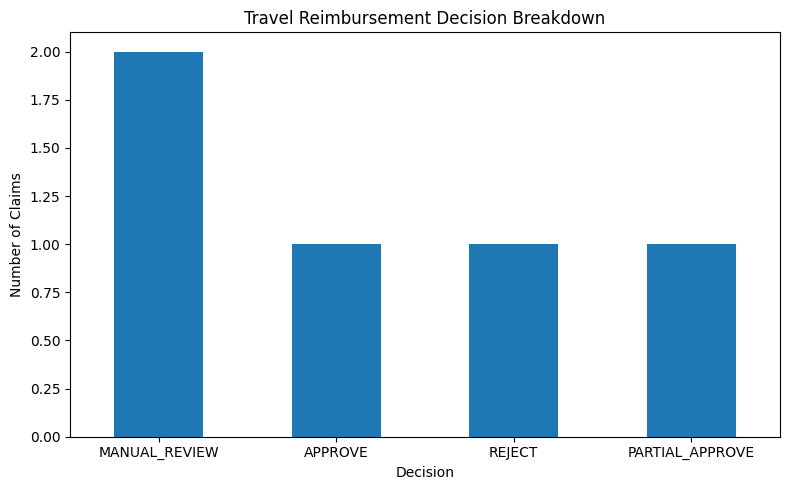

In [41]:
decision_counts = df["decision"].value_counts()

plt.figure(figsize=(8, 5))

decision_counts.plot(kind="bar")

plt.title("Travel Reimbursement Decision Breakdown")
plt.xlabel("Decision")
plt.ylabel("Number of Claims")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

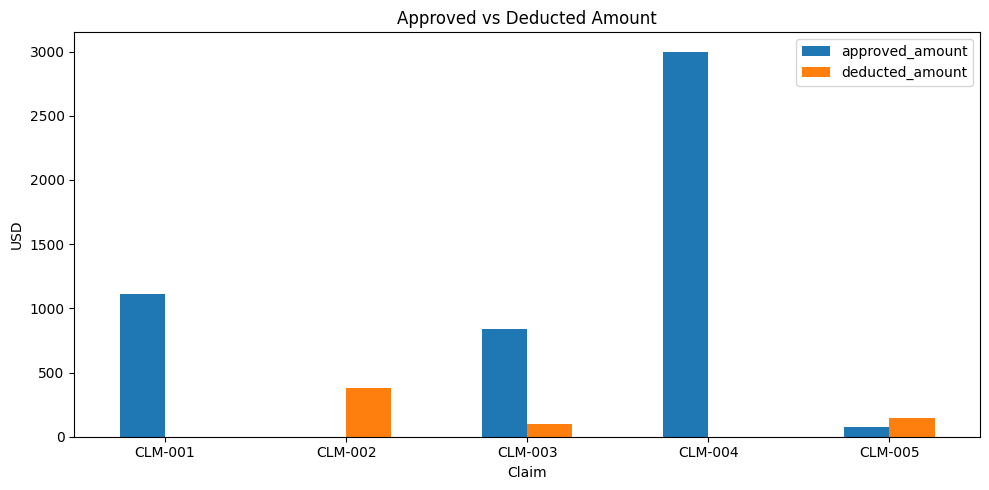

In [42]:
summary = df[
    ["claim_id", "approved_amount", "deducted_amount"]
].set_index("claim_id")

summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Approved vs Deducted Amount")
plt.xlabel("Claim")
plt.ylabel("USD")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [43]:
audit_df = pd.DataFrame([
    {
        "claim_id": result["claim_id"],
        "decision": result["decision"],
        "approved": result["approved_amount"],
        "deducted": result["deducted_amount"],
        "confidence": result["confidence"],
        "tools_called": ", ".join(result["tools_used"]),
        "policy_refs": ", ".join(result["policy_refs"])
    }
    for result in results
])

audit_df

,claim_id,decision,approved,deducted,confidence,tools_called,policy_refs
0,CLM-001,APPROVE,1110.0,0.0,0.95,"policy_lookup, receipt_check, limit_checker, a...","POL-APR-02, POL-CAT-01, POL-PD-01, POL-PD-02, ..."
1,CLM-002,REJECT,0.0,380.0,0.95,"policy_lookup, receipt_check, limit_checker, a...","POL-APR-01, POL-CAT-02, POL-TIME-01"
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.95,"policy_lookup, receipt_check, limit_checker, a...","POL-APR-02, POL-CAT-01, POL-PD-01, POL-PD-02, ..."
3,CLM-004,MANUAL_REVIEW,3000.0,0.0,0.75,"policy_lookup, receipt_check, limit_checker, a...","POL-AIR-01, POL-APR-03, POL-CAT-01, POL-PD-02,..."
4,CLM-005,MANUAL_REVIEW,75.0,145.0,0.75,"policy_lookup, receipt_check, limit_checker, a...","POL-APR-01, POL-PD-01, POL-RCT-02, POL-TIME-01"


In [44]:
def build_llm_prompt(
    claim,
    policy_context,
    tool_results
):

    return f"""
You are a Travel Reimbursement Approval Agent.

Evaluate the claim using ONLY the provided policy context
and tool results.

Do not invent policies.

Claim:
{json.dumps(claim, indent=2)}

Policy Context:
{json.dumps(policy_context, indent=2)}

Tool Results:
{json.dumps(tool_results, indent=2)}

Return:
1. Decision
2. Approved amount
3. Deducted amount
4. Missing documents
5. Policy references
6. Explanation

If there is missing information, policy exception,
or conflicting information, choose MANUAL_REVIEW.
"""